Generating Real Data...
Training GAN...
Epoch [50/1500], D_loss: -1.1989, G_loss: 1.0538
Epoch [100/1500], D_loss: -2.3828, G_loss: 1.7697
Epoch [150/1500], D_loss: -3.0011, G_loss: 1.9962
Epoch [200/1500], D_loss: -3.7582, G_loss: 3.0075
Epoch [250/1500], D_loss: -4.3359, G_loss: 3.5898
Epoch [300/1500], D_loss: -4.1858, G_loss: 3.4911
Epoch [350/1500], D_loss: -3.9387, G_loss: 3.4411
Epoch [400/1500], D_loss: -3.3564, G_loss: 2.9229
Epoch [450/1500], D_loss: -2.7973, G_loss: 2.7081
Epoch [500/1500], D_loss: -2.7451, G_loss: 2.9484
Epoch [550/1500], D_loss: -2.2988, G_loss: 2.9545
Epoch [600/1500], D_loss: -1.8038, G_loss: 3.0163
Epoch [650/1500], D_loss: -1.8621, G_loss: 3.6675
Epoch [700/1500], D_loss: -1.6602, G_loss: 3.9216
Epoch [750/1500], D_loss: -1.6740, G_loss: 4.5371
Epoch [800/1500], D_loss: -1.6385, G_loss: 4.8420
Epoch [850/1500], D_loss: -1.5414, G_loss: 4.8694
Epoch [900/1500], D_loss: -1.6579, G_loss: 5.0696
Epoch [950/1500], D_loss: -1.5960, G_loss: 5.3721
Epoch [1000

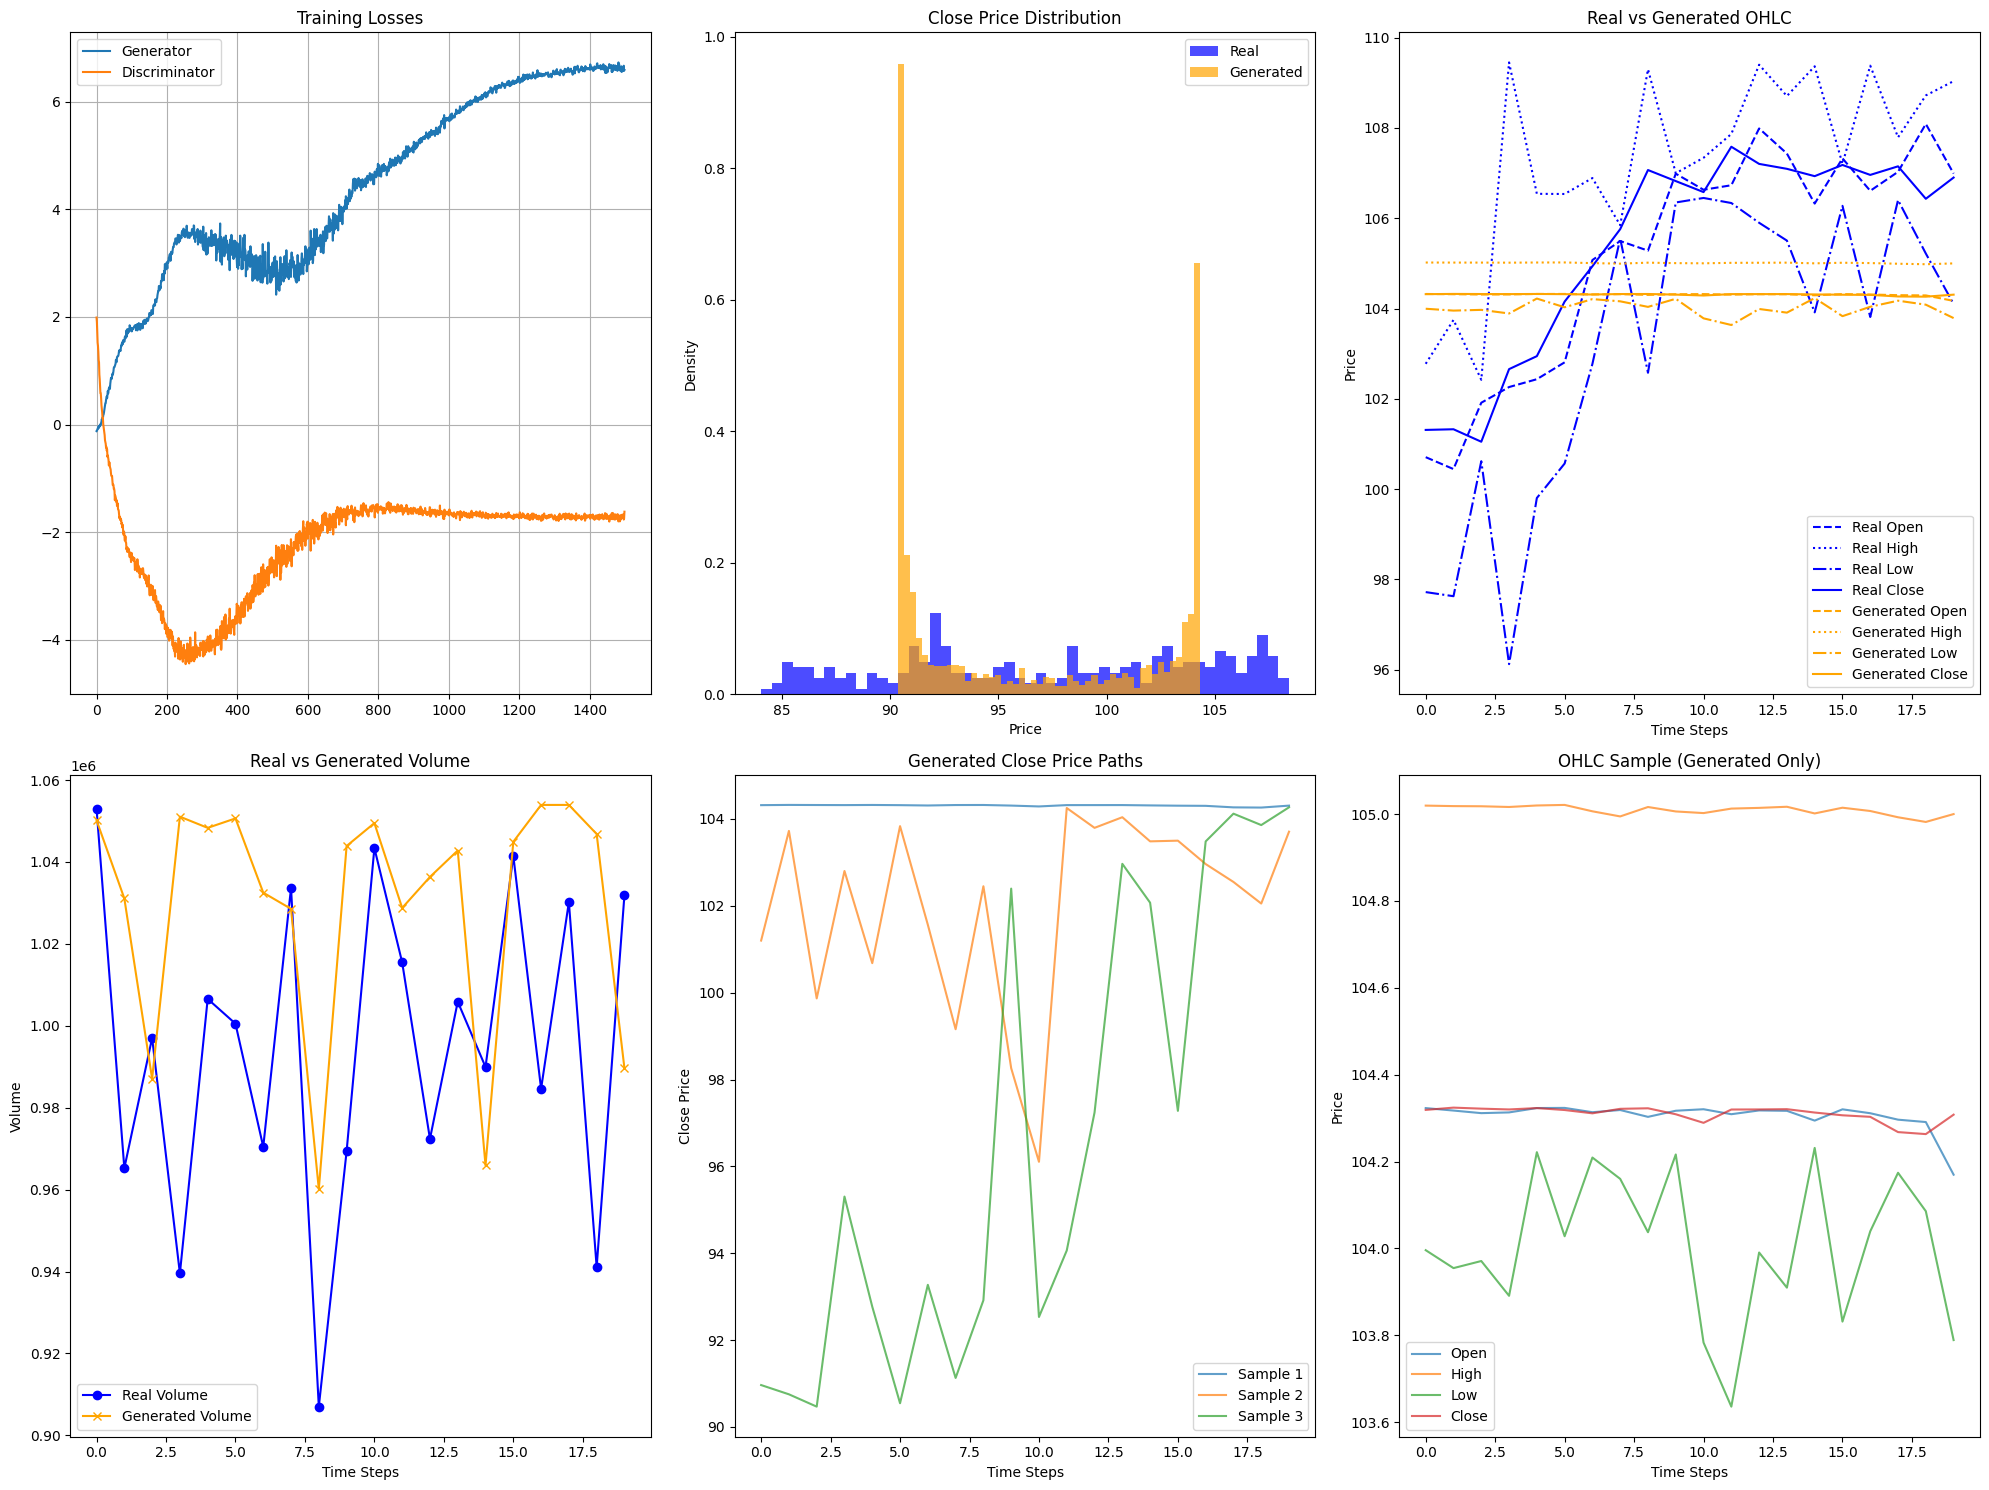

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from scipy import stats
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Configuration dictionary
config = {
    'seed': 42,
    'seq_len': 20,
    'latent_dim': 64,
    'n_epochs': 1500,
    'batch_size': 16,
    'lambda_gp': 5,
    'lr': 0.00002,
    'n_days': 250,
    'smoothness_weight': 0.1,
    'gradient_penalty_weight': 5,
    'plot_num_samples': 100,
    'sample_time_steps': 20,
    'volume_scale': 1000000,
    'noise_mean': 0.0,
    'noise_std': 0.05,
    'smoothness_penalty_power': 6
}

# Set seeds for reproducibility
torch.manual_seed(config['seed'])
np.random.seed(config['seed'])

class FinancialDataset(Dataset):
    def __init__(self, data, seq_len=config['seq_len']):
        self.price_mean = np.mean(data[:, 3])
        self.price_std = np.std(data[:, 3])
        self.vol_mean = np.mean(data[:, 4])
        self.vol_std = np.std(data[:, 4])
        
        normalized_data = np.zeros_like(data)
        for i in range(4):
            normalized_data[:, i] = (data[:, i] - self.price_mean) / self.price_std
        normalized_data[:, 4] = (data[:, 4] - self.vol_mean) / self.vol_std
        
        self.sequences = [normalized_data[i:i+seq_len] for i in range(len(normalized_data) - seq_len)]
        self.sequences = np.array(self.sequences)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.sequences[idx])
    
    def denormalize(self, data, is_volume=False):
        if is_volume:
            return data * self.vol_std + self.vol_mean
        return data * self.price_std + self.price_mean

class Generator(nn.Module):
    def __init__(self, seq_len=config['seq_len'], latent_dim=config['latent_dim']):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim

        self.price_net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, seq_len * 4),
            nn.Tanh()
        )

        self.vol_net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, seq_len),
            nn.Tanh()
        )

    def forward(self, z):
        batch_size = z.size(0)
        price_moves = self.price_net(z).view(batch_size, self.seq_len, 4)
        
        open_price = price_moves[:, :, 0]
        close_price = price_moves[:, :, 1]
        
        high_base = torch.maximum(open_price, close_price)
        high_spread = torch.abs(price_moves[:, :, 2]) * 0.1
        high_price = high_base + high_spread
        
        low_base = torch.minimum(open_price, close_price)
        low_spread = torch.abs(price_moves[:, :, 3]) * 0.1
        low_price = low_base - low_spread
        
        volume = self.vol_net(z)
        
        return torch.stack([open_price, high_price, low_price, close_price, volume], dim=2)

class Discriminator(nn.Module):
    def __init__(self, seq_len=config['seq_len']):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len * 5, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

def gradient_penalty(discriminator, real_data, fake_data):
    batch_size, seq_len, features = real_data.size()
    epsilon = torch.rand(batch_size, 1, 1).to(real_data.device)
    interpolated = epsilon * real_data + (1 - epsilon) * fake_data
    interpolated.requires_grad_(True)
    
    d_interpolated = discriminator(interpolated)
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

def create_data(n_days=config['n_days']):
    t = np.linspace(0, 4 * np.pi, n_days)
    base = 100 + t * 0.1 + np.sin(t) * 10
    base += np.random.normal(0, 1, n_days).cumsum() * 0.5
    
    data = np.zeros((n_days, 5))
    for i in range(n_days):
        vol = np.abs(np.random.normal(0, 0.02))
        data[i] = [
            base[i] * (1 + np.random.normal(0, 0.005)),
            base[i] * (1 + vol),
            base[i] * (1 - vol),
            base[i] * (1 + np.random.normal(0, 0.005)),
            np.random.lognormal(mean=config['noise_mean'], sigma=config['noise_std']) * config['volume_scale']
        ]
    return data

def train(generator, discriminator, real_data, n_epochs=config['n_epochs'], batch_size=config['batch_size'], lambda_gp=config['lambda_gp'], lr=config['lr']):
    dataset = FinancialDataset(real_data)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(0.0, 0.9))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.0, 0.9))
    
    def smoothness_penalty(fake_data):
        return torch.mean((fake_data[:, 1:, :] - fake_data[:, :-1, :]) ** config['smoothness_penalty_power'])

    g_losses, d_losses = [], []
    
    for epoch in range(n_epochs):
        epoch_g_losses = []
        epoch_d_losses = []
        
        for batch_idx, real_data_batch in enumerate(dataloader):
            batch_size = real_data_batch.size(0)
            
            d_optimizer.zero_grad()
            z = torch.randn(batch_size, generator.latent_dim)
            fake_data = generator(z)
            
            d_real = discriminator(real_data_batch)
            d_fake = discriminator(fake_data.detach())
            
            d_loss = -torch.mean(d_real) + torch.mean(d_fake)
            gp = gradient_penalty(discriminator, real_data_batch, fake_data)
            d_loss += lambda_gp * gp
            d_loss.backward()
            nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
            d_optimizer.step()
            epoch_d_losses.append(d_loss.item())
            
            if batch_idx % 2 == 0:
                g_optimizer.zero_grad()
                fake_data = generator(z)
                fake_out = discriminator(fake_data)
                
                g_loss = -torch.mean(fake_out)
                smoothness_loss = smoothness_penalty(fake_data)
                total_loss = g_loss + config['smoothness_weight'] * smoothness_loss
                total_loss.backward()
                nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
                g_optimizer.step()
                epoch_g_losses.append(total_loss.item())
        
        g_losses.append(np.mean(epoch_g_losses))
        d_losses.append(np.mean(epoch_d_losses))
        
        if (epoch + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{n_epochs}], D_loss: {d_losses[-1]:.4f}, G_loss: {g_losses[-1]:.4f}')
    
    return generator, g_losses, d_losses

def evaluate_gan(generator, real_data):
    generator.eval()
    real_data_dataset = FinancialDataset(real_data)  # For denormalizing generated data
    
    with torch.no_grad():
        z = torch.randn(config['plot_num_samples'], generator.latent_dim)
        fake_data = generator(z).numpy()  # Generate synthetic data

    # Denormalize generated data to match the real data scale
    fake_prices = real_data_dataset.denormalize(fake_data[:, :, :4])  # Denormalize OHLC prices
    fake_volume = real_data_dataset.denormalize(fake_data[:, :, 4], is_volume=True).reshape(config['plot_num_samples'], -1, 1)  # Denormalize volume
    generated_data = np.concatenate([fake_prices, fake_volume], axis=2)

    plt.figure(figsize=(20, 15))

    # 1. Training Losses Plot
    plt.subplot(2, 3, 1)
    plt.plot(g_losses, label='Generator')
    plt.plot(d_losses, label='Discriminator')
    plt.title('Training Losses')
    plt.legend()
    plt.grid(True)

    # 2. Close Price Distribution (Histogram)
    plt.subplot(2, 3, 2)
    plt.hist(real_data[:, 3], bins=50, density=True, alpha=0.7, label='Real', color='blue')
    plt.hist(fake_prices[:, :, 3].flatten(), bins=50, density=True, alpha=0.7, label='Generated', color='orange')
    plt.title('Close Price Distribution')
    plt.xlabel('Price')
    plt.ylabel('Density')
    plt.legend()

    # 3. Real vs Generated OHLC Paths
    plt.subplot(2, 3, 3)
    time_steps = np.arange(config['sample_time_steps'])
    plt.plot(time_steps, real_data[:config['sample_time_steps'], 0], label='Real Open', color='blue', linestyle='--')
    plt.plot(time_steps, real_data[:config['sample_time_steps'], 1], label='Real High', color='blue', linestyle=':')
    plt.plot(time_steps, real_data[:config['sample_time_steps'], 2], label='Real Low', color='blue', linestyle='-.')
    plt.plot(time_steps, real_data[:config['sample_time_steps'], 3], label='Real Close', color='blue')
    
    plt.plot(time_steps, fake_prices[0, :config['sample_time_steps'], 0], label='Generated Open', color='orange', linestyle='--')
    plt.plot(time_steps, fake_prices[0, :config['sample_time_steps'], 1], label='Generated High', color='orange', linestyle=':')
    plt.plot(time_steps, fake_prices[0, :config['sample_time_steps'], 2], label='Generated Low', color='orange', linestyle='-.')
    plt.plot(time_steps, fake_prices[0, :config['sample_time_steps'], 3], label='Generated Close', color='orange')
    plt.title('Real vs Generated OHLC')
    plt.xlabel('Time Steps')
    plt.ylabel('Price')
    plt.legend()

    # 4. Real vs Generated Volume Paths
    plt.subplot(2, 3, 4)
    plt.plot(time_steps, real_data[:config['sample_time_steps'], 4], label='Real Volume', color='blue', marker='o')
    plt.plot(time_steps, fake_volume[0, :config['sample_time_steps']].flatten(), label='Generated Volume', color='orange', marker='x')
    plt.title('Real vs Generated Volume')
    plt.xlabel('Time Steps')
    plt.ylabel('Volume')
    plt.legend()

    # 5. Generated Sample Paths (Generated Only)
    plt.subplot(2, 3, 5)
    for i in range(3):  # Plot three sample paths
        plt.plot(fake_prices[i, :, 3], label=f'Sample {i+1}', alpha=0.7)
    plt.title('Generated Close Price Paths')
    plt.xlabel('Time Steps')
    plt.ylabel('Close Price')
    plt.legend()

    # 6. OHLC Sample Plot for a Generated Sequence (Generated Only)
    plt.subplot(2, 3, 6)
    sample_idx = 0  # Choose the first sample for plotting
    plt.plot(fake_prices[sample_idx, :, 0], label='Open', alpha=0.7)
    plt.plot(fake_prices[sample_idx, :, 1], label='High', alpha=0.7)
    plt.plot(fake_prices[sample_idx, :, 2], label='Low', alpha=0.7)
    plt.plot(fake_prices[sample_idx, :, 3], label='Close', alpha=0.7)
    plt.title('OHLC Sample (Generated Only)')
    plt.xlabel('Time Steps')
    plt.ylabel('Price')
    plt.legend()

    plt.tight_layout()
    plt.show()
    

# Main Execution
print("Generating Real Data...")
real_data = create_data()  # Generate real data once

print("Training GAN...")
generator = Generator()
discriminator = Discriminator()
generator, g_losses, d_losses = train(generator, discriminator, real_data)  # Train the GAN model

print("\nEvaluating GAN...")
evaluate_gan(generator, real_data)  # Evaluate and plot real vs generated data


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

def create_realistic_data(n_days=1000):
    """Create realistic OHLCV financial data"""
    t = np.linspace(0, 4 * np.pi, n_days)
    
    # Generate price components
    trend = t * 0.1
    cycles = np.sin(t) * 5 + np.sin(t * 0.5) * 10
    noise = np.random.normal(0, 1, n_days).cumsum() * 0.5
    
    base = 100 + trend + cycles + noise
    
    data = np.zeros((n_days, 5))
    for i in range(n_days):
        # Generate daily volatility
        daily_vol = np.abs(np.random.normal(0, 0.015))
        
        # Generate OHLC
        open_price = base[i] * (1 + np.random.normal(0, 0.005))
        close_price = base[i] * (1 + np.random.normal(0, 0.005))
        high_price = max(open_price, close_price) * (1 + daily_vol)
        low_price = min(open_price, close_price) * (1 - daily_vol)
        
        # Generate volume with correlation to price movement
        price_change = abs(close_price - open_price)
        volume = np.random.lognormal(
            mean=np.log(1000000) + price_change * 5,
            sigma=0.5
        )
        
        data[i] = [open_price, high_price, low_price, close_price, volume]
    
    return data

class FinancialDataset(Dataset):
    def __init__(self, data, seq_len=20, use_returns=True):
        self.use_returns = use_returns
        self.seq_len = seq_len
        
        # Store original data statistics
        self.price_mean = np.mean(data[:, :4])
        self.price_std = np.std(data[:, :4])
        self.vol_mean = np.mean(data[:, 4])
        self.vol_std = np.std(data[:, 4])
        
        if use_returns:
            # Calculate returns for OHLC
            price_data = np.zeros_like(data[:, :4])
            price_data[1:] = np.log(data[1:, :4] / data[:-1, :4])
            price_data[0] = 0
            
            # Store the first actual prices for each sequence
            self.base_prices = data[:-seq_len, :4]
        else:
            # Normalize raw prices
            price_data = (data[:, :4] - self.price_mean) / self.price_std
            
        # Normalize volume
        volume_data = (data[:, 4:] - self.vol_mean) / self.vol_std
        
        # Combine price and volume data
        processed_data = np.concatenate([price_data, volume_data], axis=1)
        
        # Create sequences
        self.sequences = []
        for i in range(len(processed_data) - seq_len):
            self.sequences.append(processed_data[i:i+seq_len])
        self.sequences = np.array(self.sequences)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.sequences[idx])
    
    def denormalize(self, generated_data, start_prices=None):
        batch_size, seq_len, _ = generated_data.numpy().shape
        result = np.zeros((batch_size, seq_len, 5))
        
        if self.use_returns:
            for i in range(batch_size):
                if start_prices is not None:
                    curr_prices = start_prices[i]
                else:
                    curr_prices = self.base_prices[i].copy()
                
                result[i, 0, :4] = curr_prices
                for t in range(1, seq_len):
                    returns = generated_data[i, t, :4].numpy()
                    result[i, t, :4] = curr_prices * np.exp(returns)
                    curr_prices = result[i, t, :4]
        else:
            result[:, :, :4] = generated_data[:, :, :4].numpy() * self.price_std + self.price_mean
            
        result[:, :, 4] = generated_data[:, :, 4].numpy() * self.vol_std + self.vol_mean
        return result

class Generator(nn.Module):
    def __init__(self, seq_len=20, latent_dim=64, hidden_dim=128):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        
        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2)
        )
        
        self.project = nn.Sequential(
            nn.Linear(latent_dim, seq_len * hidden_dim),
            nn.LayerNorm(seq_len * hidden_dim),
            nn.LeakyReLU(0.2)
        )
        
        self.lstm = nn.LSTM(
            hidden_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True
        )
        
        self.price_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.LeakyReLU(0.2)
            ) for _ in range(3)
        ])
        
        self.ohlc_head = nn.Sequential(
            nn.Linear(hidden_dim, 4),
            nn.Tanh()
        )
        
        self.volume_head = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )
    
    def forward(self, z):
        batch_size = z.size(0)
        
        hidden = self.project(z).view(batch_size, self.seq_len, self.hidden_dim)
        
        time_steps = torch.arange(self.seq_len, device=z.device).float().view(1, -1, 1)
        time_embedding = self.time_embed(time_steps)
        hidden = hidden + time_embedding
        
        hidden, _ = self.lstm(hidden)
        
        for layer in self.price_layers:
            hidden = layer(hidden)
        
        ohlc = self.ohlc_head(hidden)
        volume = self.volume_head(hidden)
        
        open_price = ohlc[:, :, 0:1]
        high_price = open_price + torch.abs(ohlc[:, :, 1:2])
        low_price = open_price - torch.abs(ohlc[:, :, 2:3])
        close_price = ohlc[:, :, 3:4]
        
        return torch.cat([
            open_price,
            high_price,
            low_price,
            close_price,
            volume
        ], dim=2)

class Discriminator(nn.Module):
    def __init__(self, seq_len=20, hidden_dim=128):
        super().__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Linear(5, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1)
        )
        
        self.lstm = nn.LSTM(
            hidden_dim,
            hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.1
        )
        
        self.output = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        lstm_out, _ = self.lstm(features)
        return self.output(lstm_out[:, -1])

def gradient_penalty(discriminator, real_data, fake_data):
    batch_size = real_data.size(0)
    alpha = torch.rand(batch_size, 1, 1)
    
    interpolated = alpha * real_data + (1 - alpha) * fake_data
    interpolated.requires_grad_(True)
    
    d_interpolated = discriminator(interpolated)
    
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]
    
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    return torch.mean((gradient_norm - 1) ** 2)

def create_synthetic_data(generator, n_samples=100, seq_len=20, latent_dim=64, 
                         dataset=None, start_prices=None):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim)
        synthetic_data = generator(z)
        
        if dataset is not None:
            synthetic_data = dataset.denormalize(synthetic_data, start_prices)
            
        return synthetic_data

def train_financial_gan(generator, discriminator, train_data, config):
    default_config = {
        'n_epochs': 1000,
        'batch_size': 32,
        'lr': 0.0002,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10,
        'n_critic': 5,
        'use_returns': True,
        'seq_len': 20,
    }
    
    for k, v in default_config.items():
        if k not in config:
            config[k] = v
    
    dataset = FinancialDataset(
        train_data, 
        seq_len=config['seq_len'],
        use_returns=config['use_returns']
    )
    dataloader = DataLoader(
        dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        drop_last=True
    )
    
    g_optimizer = optim.Adam(
        generator.parameters(),
        lr=config['lr'],
        betas=(config['beta1'], config['beta2'])
    )
    d_optimizer = optim.Adam(
        discriminator.parameters(),
        lr=config['lr'],
        betas=(config['beta1'], config['beta2'])
    )
    
    g_losses = []
    d_losses = []
    
    def ohlc_consistency_loss(data):
        opens = data[:, :, 0]
        highs = data[:, :, 1]
        lows = data[:, :, 2]
        closes = data[:, :, 3]
        
        high_loss = torch.relu(opens - highs) + torch.relu(closes - highs)
        low_loss = torch.relu(lows - opens) + torch.relu(lows - closes)
        hl_loss = torch.relu(lows - highs)
        
        return torch.mean(high_loss + low_loss + hl_loss)
    
    def volatility_penalty(data):
        if config['use_returns']:
            return torch.mean(torch.abs(data[:, :, :4]) ** 2)
        else:
            price_changes = data[:, 1:, :4] - data[:, :-1, :4]
            return torch.mean(torch.abs(price_changes) ** 2)
    
    print("Starting training...")
    for epoch in range(config['n_epochs']):
        epoch_g_losses = []
        epoch_d_losses = []
        
        for batch_idx, real_batch in enumerate(dataloader):
            batch_size = real_batch.size(0)
            
            # Train Discriminator
            for _ in range(config['n_critic']):
                d_optimizer.zero_grad()
                
                z = torch.randn(batch_size, generator.latent_dim)
                fake_data = generator(z).detach()
                
                d_real = discriminator(real_batch)
                d_fake = discriminator(fake_data)
                
                gp = gradient_penalty(discriminator, real_batch, fake_data)
                
                d_loss = torch.mean(d_fake) - torch.mean(d_real) + config['lambda_gp'] * gp
                
                d_loss.backward()
                d_optimizer.step()
                epoch_d_losses.append(d_loss.item())
            
            # Train Generator
            g_optimizer.zero_grad()
            
            z = torch.randn(batch_size, generator.latent_dim)
            fake_data = generator(z)
            
            g_fake = discriminator(fake_data)
            consistency_loss = ohlc_consistency_loss(fake_data)
            vol_penalty = volatility_penalty(fake_data)
            
            g_loss = -torch.mean(g_fake) + consistency_loss + 0.1 * vol_penalty
            
            g_loss.backward()
            g_optimizer.step()
            epoch_g_losses.append(g_loss.item())
        
        g_losses.append(np.mean(epoch_g_losses))
        d_losses.append(np.mean(epoch_d_losses))
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{config['n_epochs']}] "
                  f"D_loss: {d_losses[-1]:.4f}, G_loss: {g_losses[-1]:.4f}")
            
            with torch.no_grad():
                z = torch.randn(1, generator.latent_dim)
                sample = generator(z)
                sample_data = dataset.denormalize(sample)
                print("\nSample OHLCV data:")
                print(sample_data[0, 0])
    
    return generator, discriminator, {'g_losses': g_losses, 'd_losses': d_losses}

def plot_results(real_data, synthetic_data, history):
    """Plot comparison between real and synthetic data"""
    plt.figure(figsize=(15, 10))
    
    # Plot training losses
    plt.subplot(2, 2, 1)
    plt.plot(history['g_losses'], label='Generator')
    plt.plot(history['d_losses'], label='Discriminator')
    plt.title('Training Losses')
    plt.legend()
    
    # Plot real vs synthetic prices
    plt.subplot(2, 2, 2)
    plt.plot(real_data[:20, 3], label='Real Close Price')
    plt.plot(synthetic_data[0, :20, 3], label='Synthetic Close Price')
    plt.title('Real vs Synthetic Close Prices')
    plt.legend()
    
    # Plot real vs synthetic volumes

NameError: name 'create_realistic_data' is not defined

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Test CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def create_realistic_data(n_days=250):  # Reduced from 1000 to 250 for testing
    """Create realistic OHLCV financial data"""
    print("Generating synthetic data...")
    t = np.linspace(0, 4 * np.pi, n_days)
    
    trend = t * 0.1
    cycles = np.sin(t) * 5 + np.sin(t * 0.5) * 10
    noise = np.random.normal(0, 1, n_days).cumsum() * 0.5
    
    base = 100 + trend + cycles + noise
    
    data = np.zeros((n_days, 5))
    for i in range(n_days):
        daily_vol = np.abs(np.random.normal(0, 0.015))
        open_price = base[i] * (1 + np.random.normal(0, 0.005))
        close_price = base[i] * (1 + np.random.normal(0, 0.005))
        high_price = max(open_price, close_price) * (1 + daily_vol)
        low_price = min(open_price, close_price) * (1 - daily_vol)
        volume = np.random.lognormal(mean=np.log(1000000), sigma=0.5)
        data[i] = [open_price, high_price, low_price, close_price, volume]
    
    print("Data generation complete!")
    return data

class FinancialDataset(Dataset):
    def __init__(self, data, seq_len=20, use_returns=True):
        print("Initializing dataset...")
        self.use_returns = use_returns
        self.seq_len = seq_len
        
        self.price_mean = np.mean(data[:, :4])
        self.price_std = np.std(data[:, :4])
        self.vol_mean = np.mean(data[:, 4])
        self.vol_std = np.std(data[:, 4])
        
        if use_returns:
            price_data = np.zeros_like(data[:, :4])
            price_data[1:] = np.log(data[1:, :4] / data[:-1, :4])
            price_data[0] = 0
            self.base_prices = data[:-seq_len, :4]
        else:
            price_data = (data[:, :4] - self.price_mean) / self.price_std
            
        volume_data = (data[:, 4:] - self.vol_mean) / self.vol_std
        processed_data = np.concatenate([price_data, volume_data], axis=1)
        
        self.sequences = []
        for i in range(len(processed_data) - seq_len):
            self.sequences.append(processed_data[i:i+seq_len])
        self.sequences = np.array(self.sequences)
        print("Dataset initialization complete!")
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.sequences[idx])

class Generator(nn.Module):
    def __init__(self, seq_len=20, latent_dim=64, hidden_dim=128):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        
        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2)
        )
        
        self.project = nn.Sequential(
            nn.Linear(latent_dim, seq_len * hidden_dim),
            nn.LayerNorm(seq_len * hidden_dim),
            nn.LeakyReLU(0.2)
        )
        
        self.lstm = nn.LSTM(
            hidden_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True
        )
        
        self.price_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.LeakyReLU(0.2)
            ) for _ in range(3)
        ])
        
        self.ohlc_head = nn.Sequential(
            nn.Linear(hidden_dim, 4),
            nn.Tanh()
        )
        
        self.volume_head = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )
    
    def forward(self, z):
        batch_size = z.size(0)
        
        hidden = self.project(z).view(batch_size, self.seq_len, self.hidden_dim)
        
        time_steps = torch.arange(self.seq_len, device=z.device).float().view(1, -1, 1)
        time_embedding = self.time_embed(time_steps)
        hidden = hidden + time_embedding
        
        hidden, _ = self.lstm(hidden)
        
        for layer in self.price_layers:
            hidden = layer(hidden)
        
        ohlc = self.ohlc_head(hidden)
        volume = self.volume_head(hidden)
        
        open_price = ohlc[:, :, 0:1]
        high_price = open_price + torch.abs(ohlc[:, :, 1:2])
        low_price = open_price - torch.abs(ohlc[:, :, 2:3])
        close_price = ohlc[:, :, 3:4]
        
        return torch.cat([
            open_price,
            high_price,
            low_price,
            close_price,
            volume
        ], dim=2)

class Discriminator(nn.Module):
    def __init__(self, seq_len=20, hidden_dim=128):
        super().__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Linear(5, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1)
        )
        
        self.lstm = nn.LSTM(
            hidden_dim,
            hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.1
        )
        
        self.output = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        lstm_out, _ = self.lstm(features)
        return self.output(lstm_out[:, -1])

def gradient_penalty(discriminator, real_data, fake_data):
    batch_size = real_data.size(0)
    alpha = torch.rand(batch_size, 1, 1)
    
    interpolated = alpha * real_data + (1 - alpha) * fake_data
    interpolated.requires_grad_(True)
    
    d_interpolated = discriminator(interpolated)
    
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]
    
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    return torch.mean((gradient_norm - 1) ** 2)

def create_synthetic_data(generator, n_samples=100, seq_len=20, latent_dim=64, 
                         dataset=None, start_prices=None):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim)
        synthetic_data = generator(z)
        
        if dataset is not None:
            synthetic_data = dataset.denormalize(synthetic_data, start_prices)
            
        return synthetic_data

def train_financial_gan(generator, discriminator, train_data, config):
    print("Starting GAN training setup...")
    
    default_config = {
        'n_epochs': 100,  # Reduced from 1000 to 100 for testing
        'batch_size': 32,
        'lr': 0.0002,
        'beta1': 0.0,
        'beta2': 0.9,
        'lambda_gp': 10,
        'n_critic': 5,
        'use_returns': True,
        'seq_len': 20,
    }
    
    config = {**default_config, **config}
    
    # Move models to device
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    
    dataset = FinancialDataset(
        train_data, 
        seq_len=config['seq_len'],
        use_returns=config['use_returns']
    )
    
    dataloader = DataLoader(
        dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        drop_last=True
    )
    
    g_optimizer = optim.Adam(
        generator.parameters(),
        lr=config['lr'],
        betas=(config['beta1'], config['beta2'])
    )
    d_optimizer = optim.Adam(
        discriminator.parameters(),
        lr=config['lr'],
        betas=(config['beta1'], config['beta2'])
    )
    
    print(f"Starting training for {config['n_epochs']} epochs...")
    
    g_losses = []
    d_losses = []
    
    # Training loop with progress bar
    epochs = tqdm(range(config['n_epochs']), desc="Training Progress")
    for epoch in epochs:
        epoch_g_losses = []
        epoch_d_losses = []
        
        for batch_idx, real_batch in enumerate(dataloader):
            batch_size = real_batch.size(0)
            real_batch = real_batch.to(device)
            
            # Train Discriminator
            for _ in range(config['n_critic']):
                d_optimizer.zero_grad()
                
                z = torch.randn(batch_size, generator.latent_dim, device=device)
                fake_data = generator(z).detach()
                
                d_real = discriminator(real_batch)
                d_fake = discriminator(fake_data)
                
                # Gradient penalty
                alpha = torch.rand(batch_size, 1, 1, device=device)
                interpolated = alpha * real_batch + (1 - alpha) * fake_data
                interpolated.requires_grad_(True)
                d_interpolated = discriminator(interpolated)
                gradients = torch.autograd.grad(
                    outputs=d_interpolated,
                    inputs=interpolated,
                    grad_outputs=torch.ones_like(d_interpolated, device=device),
                    create_graph=True,
                    retain_graph=True
                )[0]
                
                gradient_norm = gradients.view(batch_size, -1).norm(2, dim=1)
                gradient_penalty = ((gradient_norm - 1) ** 2).mean()
                
                d_loss = torch.mean(d_fake) - torch.mean(d_real) + config['lambda_gp'] * gradient_penalty
                
                d_loss.backward()
                d_optimizer.step()
                epoch_d_losses.append(d_loss.item())
            
            # Train Generator
            g_optimizer.zero_grad()
            
            z = torch.randn(batch_size, generator.latent_dim, device=device)
            fake_data = generator(z)
            g_fake = discriminator(fake_data)
            
            g_loss = -torch.mean(g_fake)
            
            g_loss.backward()
            g_optimizer.step()
            epoch_g_losses.append(g_loss.item())
        
        # Update progress bar with losses
        avg_g_loss = np.mean(epoch_g_losses)
        avg_d_loss = np.mean(epoch_d_losses)
        epochs.set_postfix({
            'G_Loss': f'{avg_g_loss:.4f}',
            'D_Loss': f'{avg_d_loss:.4f}'
        })
        
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        
        # Generate sample every 10 epochs
        if (epoch + 1) % 10 == 0:
            with torch.no_grad():
                z = torch.randn(1, generator.latent_dim, device=device)
                sample = generator(z)
                sample_data = dataset.denormalize(sample.cpu())
                print(f"\nEpoch {epoch+1} Sample OHLCV:")
                print(sample_data[0, 0])
    
    print("Training complete!")
    return generator, discriminator, {'g_losses': g_losses, 'd_losses': d_losses}

def plot_financial_comparison(real_data, synthetic_data, history, num_samples=3, seq_length=50):
    """
    Plot comprehensive comparison between real and synthetic financial data
    
    Args:
        real_data: numpy array of real OHLCV data
        synthetic_data: numpy array of generated OHLCV data
        history: dictionary containing training losses
        num_samples: number of synthetic samples to plot
        seq_length: number of time steps to plot
    """
    plt.style.use('seaborn')
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Training Losses
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(history['g_losses'], label='Generator', alpha=0.8)
    ax1.plot(history['d_losses'], label='Discriminator', alpha=0.8)
    ax1.set_title('Training Losses', fontsize=12)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # 2. OHLC Comparison
    ax2 = plt.subplot(3, 2, 2)
    # Plot real OHLC
    real_subset = real_data[:seq_length]
    ax2.plot(real_subset[:, 0], label='Real Open', linestyle='--', alpha=0.5)
    ax2.plot(real_subset[:, 1], label='Real High', linestyle=':', alpha=0.5)
    ax2.plot(real_subset[:, 2], label='Real Low', linestyle='-.', alpha=0.5)
    ax2.plot(real_subset[:, 3], label='Real Close', alpha=0.5)
    
    # Plot synthetic OHLC
    syn_subset = synthetic_data[0, :seq_length]
    ax2.plot(syn_subset[:, 0], label='Synthetic Open', linestyle='--')
    ax2.plot(syn_subset[:, 1], label='Synthetic High', linestyle=':')
    ax2.plot(syn_subset[:, 2], label='Synthetic Low', linestyle='-.')
    ax2.plot(syn_subset[:, 3], label='Synthetic Close')
    
    ax2.set_title('Real vs Synthetic OHLC Comparison', fontsize=12)
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Price')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True)
    
    # 3. Individual Price Components
    titles = ['Open', 'High', 'Low', 'Close']
    for i, title in enumerate(titles):
        ax = plt.subplot(3, 2, i + 3)
        
        # Plot real data
        ax.plot(real_subset[:, i], label='Real', color='blue', alpha=0.6)
        
        # Plot multiple synthetic samples
        for j in range(num_samples):
            ax.plot(synthetic_data[j, :seq_length, i], 
                   label=f'Synthetic {j+1}' if j == 0 else None,
                   color='orange', alpha=0.3)
        
        ax.set_title(f'{title} Price Comparison', fontsize=12)
        ax.set_xlabel('Time Steps')
        ax.set_ylabel('Price')
        ax.legend()
        ax.grid(True)
    
    # 4. Distributions
    fig2 = plt.figure(figsize=(20, 10))
    
    # Price distributions
    for i, title in enumerate(titles):
        ax = plt.subplot(2, 3, i + 1)
        
        # Calculate ranges for consistent bins
        min_val = min(real_data[:, i].min(), synthetic_data[:, :, i].min())
        max_val = max(real_data[:, i].max(), synthetic_data[:, :, i].max())
        bins = np.linspace(min_val, max_val, 50)
        
        ax.hist(real_data[:, i], bins=bins, alpha=0.5, label='Real', 
               density=True, color='blue')
        ax.hist(synthetic_data[:, :, i].flatten(), bins=bins, alpha=0.5, 
                label='Synthetic', density=True, color='orange')
        
        ax.set_title(f'{title} Price Distribution', fontsize=12)
        ax.set_xlabel('Price')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True)
    
    # Volume distribution
    ax = plt.subplot(2, 3, 5)
    min_vol = min(real_data[:, 4].min(), synthetic_data[:, :, 4].min())
    max_vol = max(real_data[:, 4].max(), synthetic_data[:, :, 4].max())
    vol_bins = np.linspace(min_vol, max_vol, 50)
    
    ax.hist(real_data[:, 4], bins=vol_bins, alpha=0.5, label='Real', 
           density=True, color='blue')
    ax.hist(synthetic_data[:, :, 4].flatten(), bins=vol_bins, alpha=0.5, 
            label='Synthetic', density=True, color='orange')
    
    ax.set_title('Volume Distribution', fontsize=12)
    ax.set_xlabel('Volume')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True)
    
    # Returns/Changes distribution
    ax = plt.subplot(2, 3, 6)
    real_returns = np.diff(real_data[:, 3]) / real_data[:-1, 3]
    synthetic_returns = np.diff(synthetic_data[0, :, 3]) / synthetic_data[0, :-1, 3]
    
    min_ret = min(real_returns.min(), synthetic_returns.min())
    max_ret = max(real_returns.max(), synthetic_returns.max())
    ret_bins = np.linspace(min_ret, max_ret, 50)
    
    ax.hist(real_returns, bins=ret_bins, alpha=0.5, label='Real', 
           density=True, color='blue')
    ax.hist(synthetic_returns, bins=ret_bins, alpha=0.5, 
            label='Synthetic', density=True, color='orange')
    
    ax.set_title('Return Distribution (Close Price)', fontsize=12)
    ax.set_xlabel('Returns')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True)
    
    # Adjust layout and display
    fig.tight_layout()
    fig2.tight_layout()
    plt.show()
    
    # Print some statistics
    print("\nStatistics Comparison:")
    print("\nReal Data:")
    print(f"Mean OHLC: {np.mean(real_data[:, :4], axis=0)}")
    print(f"Std OHLC: {np.std(real_data[:, :4], axis=0)}")
    print(f"Mean Volume: {np.mean(real_data[:, 4])}")
    print(f"Std Volume: {np.std(real_data[:, 4])}")
    
    print("\nSynthetic Data:")
    print(f"Mean OHLC: {np.mean(synthetic_data[:, :, :4], axis=(0,1))}")
    print(f"Std OHLC: {np.std(synthetic_data[:, :, :4], axis=(0,1))}")
    print(f"Mean Volume: {np.mean(synthetic_data[:, :, 4])}")
    print(f"Std Volume: {np.std(synthetic_data[:, :, 4])}")

# Example usage:
# if __name__ == "__main__":
# Generate real data
torch.manual_seed(42)
np.random.seed(42)

# Generate smaller dataset for testing
real_data = create_realistic_data(n_days=250)  # Reduced size

# Initialize models
generator = Generator()
discriminator = Discriminator()

# Training configuration
config = {
    'n_epochs': 100,  # Reduced epochs
    'batch_size': 32,
    'lr': 0.0002,
    'use_returns': True
}

# Train the GAN
generator, discriminator, history = train_financial_gan(
    generator,
    discriminator,
    real_data,
    config
)

# Generate synthetic data
print("Generating synthetic data...")
dataset = FinancialDataset(real_data, use_returns=config['use_returns'])
synthetic_data = create_synthetic_data(
    generator,
    n_samples=50,  # Reduced samples
    dataset=dataset
)

# Plot results
print("Plotting results...")
plot_financial_comparison(real_data, synthetic_data, history)

print("Process complete!")
# return generator, discriminator, synthetic_data, history
# Plot real vs synthetic volumes

Using device: cpu
Generating synthetic data...
Data generation complete!
Starting GAN training setup...
Initializing dataset...
Dataset initialization complete!
Starting training for 100 epochs...


Training Progress:   2%|▏         | 2/100 [01:32<1:15:40, 46.34s/it, G_Loss=1.0756, D_Loss=-1.2975]


KeyboardInterrupt: 

Starting training...


 28%|██▊       | 14/50 [00:00<00:01, 33.96it/s]


Epoch [10/50] D_loss: 0.1834, G_loss: 0.4000


 52%|█████▏    | 26/50 [00:00<00:00, 32.96it/s]


Epoch [20/50] D_loss: 0.1221, G_loss: 0.5512


...


Epoch [30/50] D_loss: 0.1002, G_loss: 0.5865


 94%|█████████▍| 47/50 [00:01<00:00, 37.53it/s]


Epoch [40/50] D_loss: 0.1041, G_loss: 0.5880


100%|██████████| 50/50 [00:01<00:00, 34.48it/s]



Epoch [50/50] D_loss: 0.0835, G_loss: 0.6191


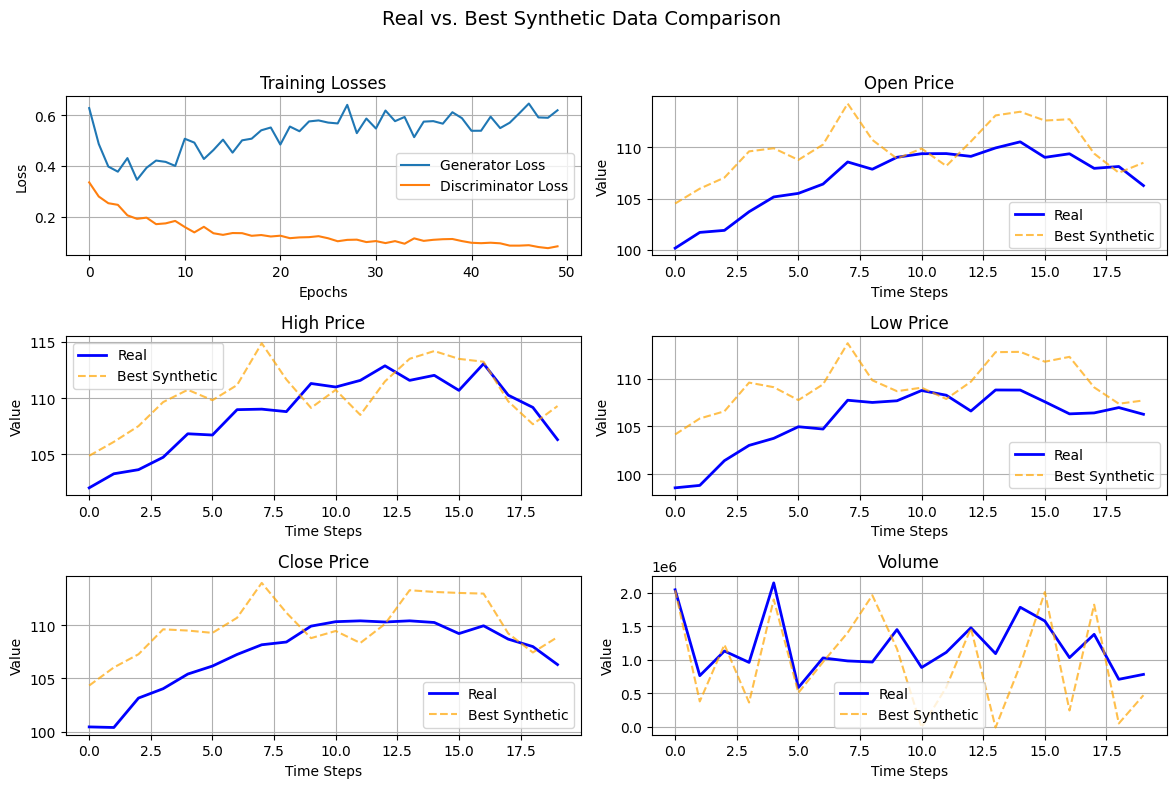

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def create_realistic_data(n_days=100):
    """Create realistic OHLCV financial data"""
    t = np.linspace(0, 4 * np.pi, n_days)
    base = 100 + t * 0.1 + np.sin(t) * 10
    
    data = np.zeros((n_days, 5))
    for i in range(n_days):
        daily_vol = np.abs(np.random.normal(0, 0.01))
        open_price = base[i] * (1 + np.random.normal(0, 0.005))
        close_price = base[i] * (1 + np.random.normal(0, 0.005))
        high_price = max(open_price, close_price) * (1 + daily_vol)
        low_price = min(open_price, close_price) * (1 - daily_vol)
        volume = np.random.lognormal(mean=np.log(1000000), sigma=0.5)
        
        data[i] = [open_price, high_price, low_price, close_price, volume]
    
    return data

class FinancialDataset(Dataset):
    def __init__(self, data, seq_len=20):
        self.orig_data = data.copy()
        self.seq_len = seq_len
        
        # Calculate statistics for OHLC
        self.price_mean = np.mean(data[:, :4])
        self.price_std = np.std(data[:, :4])
        
        # Calculate statistics for volume
        self.vol_mean = np.mean(data[:, 4])
        self.vol_std = np.std(data[:, 4])
        
        # Normalize data
        norm_data = np.zeros_like(data)
        norm_data[:, :4] = (data[:, :4] - self.price_mean) / self.price_std
        norm_data[:, 4] = (data[:, 4] - self.vol_mean) / self.vol_std
        
        # Create sequences
        self.sequences = []
        for i in range(len(norm_data) - seq_len):
            self.sequences.append(norm_data[i:i+seq_len])
        self.sequences = np.array(self.sequences)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.sequences[idx])
    
    def denormalize(self, data):
        data = data.detach().cpu().numpy() if torch.is_tensor(data) else data
        result = np.zeros_like(data)
        result[:, :, :4] = data[:, :, :4] * self.price_std + self.price_mean
        result[:, :, 4] = data[:, :, 4] * self.vol_std + self.vol_mean
        return result

class Discriminator(nn.Module):
    def __init__(self, seq_len=20):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len * 5, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

class Generator(nn.Module):
    def __init__(self, seq_len=20, latent_dim=32):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim
        
        # Shared base - keep it simple
        self.shared = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
        )
        
        # Separate heads for trend and noise
        self.trend = nn.Linear(128, seq_len)
        self.noise = nn.Linear(128, seq_len)
        
        # Separate volume network (no shared features)
        self.volume = nn.Sequential(
            nn.Linear(latent_dim, 128),  # Takes raw z input
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, seq_len),
            nn.Tanh()
        )
    
    def forward(self, z):
        batch_size = z.size(0)
        h = self.shared(z)
        
        # Generate trend component
        trend = torch.cumsum(self.trend(h), dim=1).unsqueeze(-1)
        noise = 0.1 * self.noise(h).unsqueeze(-1)
        
        # Base price combining trend and noise
        base_price = trend + noise
        
        # Generate OHLC from base price
        open_price = base_price
        high_price = base_price + torch.abs(noise)
        low_price = base_price - torch.abs(noise)
        close_price = base_price + 0.5 * noise
        
        # Volume - using the separate network
        volume = self.volume(z).unsqueeze(-1) * 5  # Use raw z, not shared h
        
        return torch.cat([
            open_price,
            high_price,
            low_price,
            close_price,
            volume
        ], dim=2)

def train_financial_gan(generator, discriminator, train_data, config):
    print("Starting training...")
    
    default_config = {
        'n_epochs': 50,
        'batch_size': 16,
        'lr': 0.0001,
        'beta1': 0.5,
        'beta2': 0.999
    }
    config = {**default_config, **config}
    
    dataset = FinancialDataset(train_data, seq_len=20)
    dataloader = DataLoader(dataset, batch_size=config['batch_size'], shuffle=True)
    
    g_optimizer = optim.Adam(generator.parameters(), lr=config['lr'], 
                           betas=(config['beta1'], config['beta2']))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=config['lr'],
                           betas=(config['beta1'], config['beta2']))
    
    def price_consistency_loss(data):
        """Focus on trend consistency and reduced volatility"""
        prices = data[:, :, :4]
        
        # Price relationships
        highs = prices[:, :, 1]
        lows = prices[:, :, 2]
        relationship_loss = torch.relu(lows - highs).mean()
        
        # Trend consistency
        price_changes = torch.diff(prices[:, :, 3], dim=1)  # Use close prices
        trend_changes = torch.diff(price_changes, dim=1)
        trend_loss = torch.abs(trend_changes).mean()  # Penalize trend changes
        
        # Volatility control
        volatility_loss = torch.abs(price_changes).mean()
        
        return relationship_loss + 0.1 * trend_loss + 0.05 * volatility_loss
    
    g_losses, d_losses = [], []
    
    for epoch in tqdm(range(config['n_epochs'])):
        epoch_g_losses = []
        epoch_d_losses = []
        
        for real_batch in dataloader:
            batch_size = real_batch.size(0)
            
            # Train Discriminator
            d_optimizer.zero_grad()
            
            z = torch.randn(batch_size, generator.latent_dim)
            fake_data = generator(z).detach()
            
            d_real = discriminator(real_batch)
            d_fake = discriminator(fake_data)
            
            # Simple MSE loss for stability
            d_loss = (torch.mean((d_real - 1)**2) + torch.mean(d_fake**2)) / 2
            
            d_loss.backward()
            d_optimizer.step()
            
            # Train Generator
            g_optimizer.zero_grad()
            
            z = torch.randn(batch_size, generator.latent_dim)
            fake_data = generator(z)
            g_fake = discriminator(fake_data)
            
            # Generator losses
            g_loss = torch.mean((g_fake - 1)**2)
            consistency = price_consistency_loss(fake_data)
            
            total_g_loss = g_loss + consistency
            
            total_g_loss.backward()
            g_optimizer.step()
            
            epoch_g_losses.append(g_loss.item())
            epoch_d_losses.append(d_loss.item())
        
        g_losses.append(np.mean(epoch_g_losses))
        d_losses.append(np.mean(epoch_d_losses))
        
        if (epoch + 1) % 10 == 0:
            print(f"\nEpoch [{epoch+1}/{config['n_epochs']}] "
                  f"D_loss: {d_losses[-1]:.4f}, G_loss: {g_losses[-1]:.4f}")
    
    return generator, discriminator, {'g_losses': g_losses, 'd_losses': d_losses}

def plot_comparison(real_data, synthetic_data, history, window=20):
    # plt.style.use('seaborn')
    
    # First figure: OHLC plots
    fig1 = plt.figure(figsize=(20, 12))
    
    # 1. Plot losses
    plt.subplot(2, 2, 1)
    plt.plot(history['g_losses'], label='Generator')
    plt.plot(history['d_losses'], label='Discriminator')
    plt.title('Training Losses')
    plt.legend()
    plt.grid(True)
    
    # 2. Plot OHLC
    def plot_sequence(ax, real_seq, synth_seqs, idx, title):
        ax.plot(real_seq[:window, idx], label='Real', color='blue', linewidth=2)
        for i, syn_data in enumerate(synth_seqs[:3]):
            ax.plot(syn_data[:window, idx], 
                   label=f'Synthetic {i+1}', 
                   alpha=0.6,
                   linestyle='--')
        ax.set_title(title)
        ax.legend()
        ax.grid(True)
    
    # Plot Open prices
    plt.subplot(2, 2, 2)
    plot_sequence(plt.gca(), real_data, synthetic_data, 0, 'Real vs Synthetic Open Prices')
    
    # Plot High-Low prices
    plt.subplot(2, 2, 3)
    plt.plot(real_data[:window, 1], label='Real High', color='blue', linestyle='--')
    plt.plot(real_data[:window, 2], label='Real Low', color='blue', linestyle=':')
    for i in range(min(3, len(synthetic_data))):
        plt.plot(synthetic_data[i, :window, 1], 
                label=f'Synthetic High {i+1}',
                alpha=0.6,
                linestyle='--')
        plt.plot(synthetic_data[i, :window, 2], 
                label=f'Synthetic Low {i+1}',
                alpha=0.6,
                linestyle=':')
    plt.title('Real vs Synthetic High-Low Prices')
    plt.legend()
    plt.grid(True)
    
    # Plot Close prices
    plt.subplot(2, 2, 4)
    plot_sequence(plt.gca(), real_data, synthetic_data, 3, 'Real vs Synthetic Close Prices')
    
    plt.tight_layout()
    plt.show()
    
    # Second figure: Volume plots
    fig2 = plt.figure(figsize=(15, 6))
    
    # Volume time series
    plt.subplot(1, 2, 1)
    plt.plot(real_data[:window, 4], label='Real Volume', color='blue', linewidth=2)
    for i in range(min(3, len(synthetic_data))):
        plt.plot(synthetic_data[i, :window, 4], 
                label=f'Synthetic Volume {i+1}',
                alpha=0.6,
                linestyle='--')
    plt.title('Real vs Synthetic Volume')
    plt.legend()
    plt.grid(True)
    
    # Volume distribution
    plt.subplot(1, 2, 2)
    plt.hist(real_data[:, 4], bins=30, alpha=0.5, label='Real Volume', 
            density=True, color='blue')
    plt.hist(synthetic_data[:, :, 4].flatten(), bins=30, alpha=0.5,
            label='Synthetic Volume', density=True, color='orange')
    plt.title('Volume Distribution')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def select_best_synthetic_sequence(real_seq, synthetic_seqs):
    """
    Selects the best synthetic sequence based on Mean Squared Error with the real data.
    real_seq and synth_seq are truncated to match the window length.
    """
    # Ensure real_seq and each synthetic sequence have the same length for comparison
    real_seq_truncated = real_seq[:len(synthetic_seqs[0])]
    errors = [np.mean((real_seq_truncated - synth_seq) ** 2) for synth_seq in synthetic_seqs]
    best_index = np.argmin(errors)
    return synthetic_seqs[best_index]

def plot_comparison(real_data, synthetic_data, history, window=20):
    # Select the best synthetic sequences for each feature against the real data
    best_synthetic_data = [select_best_synthetic_sequence(real_data[:window, i], synthetic_data[:, :window, i]) for i in range(5)]
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 8))
    fig.suptitle("Real vs. Best Synthetic Data Comparison", fontsize=14)
    axes = axes.flatten()

    # 1. Plot Training Losses
    axes[0].plot(history['g_losses'], label='Generator Loss')
    axes[0].plot(history['d_losses'], label='Discriminator Loss')
    axes[0].set_title('Training Losses')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Helper function to plot real vs best synthetic for specific price features
    def plot_feature_comparison(ax, real_seq, best_synth_seq, title):
        ax.plot(real_seq[:window], label='Real', color='blue', linewidth=2)
        ax.plot(best_synth_seq[:window], label='Best Synthetic', linestyle='--', color='orange', alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel('Time Steps')
        ax.set_ylabel('Value')
        ax.legend()
        ax.grid(True)

    # 2. Open Price
    plot_feature_comparison(axes[1], real_data[:, 0], best_synthetic_data[0], 'Open Price')

    # 3. High Price
    plot_feature_comparison(axes[2], real_data[:, 1], best_synthetic_data[1], 'High Price')

    # 4. Low Price
    plot_feature_comparison(axes[3], real_data[:, 2], best_synthetic_data[2], 'Low Price')

    # 5. Close Price
    plot_feature_comparison(axes[4], real_data[:, 3], best_synthetic_data[3], 'Close Price')

    # 6. Volume
    plot_feature_comparison(axes[5], real_data[:, 4], best_synthetic_data[4], 'Volume')

    fig.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit title
    plt.show()



def main():
    # Generate data
    real_data = create_realistic_data(n_days=100)
    
    # Initialize models
    generator = Generator(seq_len=20, latent_dim=32)
    discriminator = Discriminator(seq_len=20)
    
    # Training configuration
    config = {
        'n_epochs': 50,
        'batch_size': 16,
        'lr': 0.0001
    }
    
    # Train
    generator, discriminator, history = train_financial_gan(
        generator,
        discriminator,
        real_data,
        config
    )
    
    # Generate synthetic data
    with torch.no_grad():
        z = torch.randn(10, generator.latent_dim)
        synthetic_data = generator(z)
        dataset = FinancialDataset(real_data, seq_len=20)
        synthetic_data = dataset.denormalize(synthetic_data)
    
    # Plot results
    plot_comparison(real_data, synthetic_data, history)

if __name__ == "__main__":
    main()

Epoch [50/500], D_loss: 0.5257, G_loss: 0.9006
Epoch [100/500], D_loss: 0.3760, G_loss: 1.1824
Epoch [150/500], D_loss: 0.2446, G_loss: 1.5485
Epoch [200/500], D_loss: 0.1791, G_loss: 1.8264
Epoch [250/500], D_loss: 0.1030, G_loss: 2.3403
Epoch [300/500], D_loss: 0.0651, G_loss: 2.7796
Epoch [350/500], D_loss: 0.0453, G_loss: 3.1645
Epoch [400/500], D_loss: 0.0278, G_loss: 3.6051
Epoch [450/500], D_loss: 0.0207, G_loss: 3.9374
Epoch [500/500], D_loss: 0.0164, G_loss: 4.1710


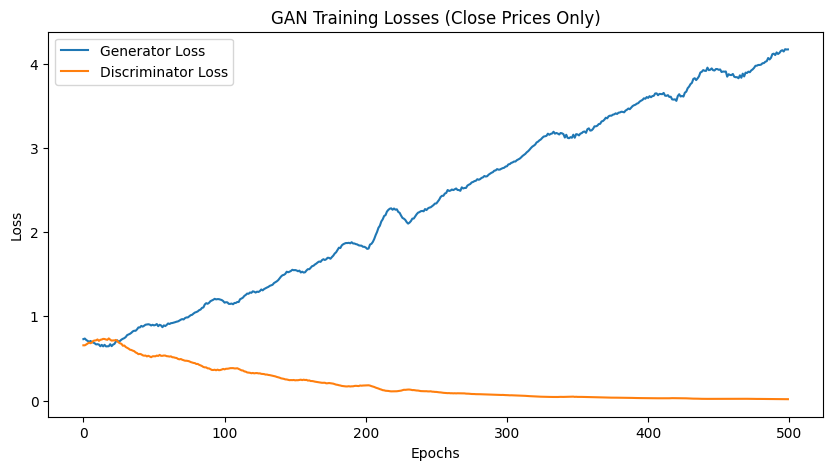

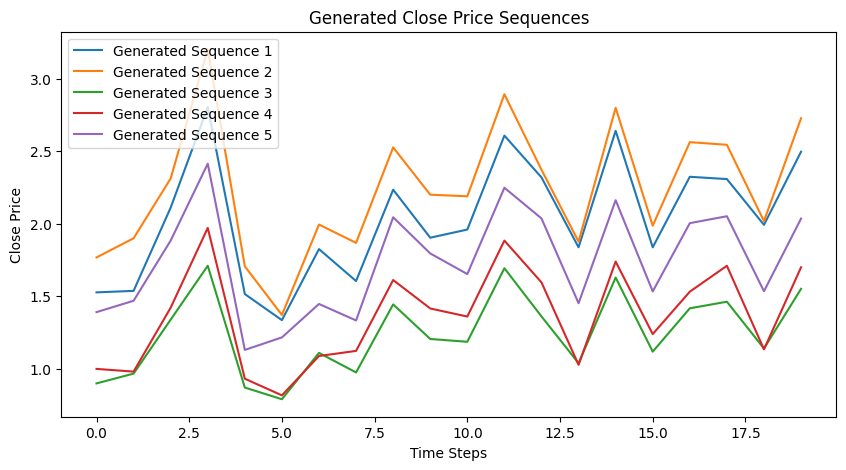

In [3]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# import matplotlib.pyplot as plt

# Set random seeds for reproducibility
# torch.manual_seed(0)
# np.random.seed(0)

# Configuration for the baseline model
config = {
    'seq_len': 20,         # Sequence length (number of time steps)
    'latent_dim': 10,      # Latent dimension for Generator input
    'n_epochs': 500,       # Number of training epochs
    'batch_size': 16,      # Batch size
    'lr': 0.0002,          # Learning rate
}

# Step 1: Simplified Dataset with Minimal Data (Close Prices Only)
def create_close_price_data(n_samples=100):
    t = np.linspace(0, 2 * np.pi, n_samples)
    close_prices = 100 + np.sin(t) * 10 + np.random.normal(0, 0.5, n_samples)  # Simplified sinusoidal data
    sequences = [close_prices[i:i+config['seq_len']] for i in range(n_samples - config['seq_len'])]
    return torch.tensor(sequences, dtype=torch.float32).unsqueeze(-1)

# Generator model
class SimpleGenerator(nn.Module):
    def __init__(self, seq_len=config['seq_len'], latent_dim=config['latent_dim']):
        super(SimpleGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, seq_len)
        )

    def forward(self, z):
        return self.net(z).unsqueeze(-1)

# Discriminator model
class SimpleDiscriminator(nn.Module):
    def __init__(self, seq_len=config['seq_len']):
        super(SimpleDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Step 2: Training the GAN on the Close Price Data
def train_gan(generator, discriminator, real_data, config):
    # Optimizers for generator and discriminator
    g_optimizer = optim.Adam(generator.parameters(), lr=config['lr'])
    d_optimizer = optim.Adam(discriminator.parameters(), lr=config['lr'])

    criterion = nn.BCELoss()
    g_losses, d_losses = [], []

    for epoch in range(config['n_epochs']):
        for batch in real_data:
            batch_size = batch.size(0)

            # Train Discriminator
            z = torch.randn(batch_size, config['latent_dim'])
            fake_data = generator(z)
            real_labels = torch.ones(batch_size, 1)
            fake_labels = torch.zeros(batch_size, 1)

            # Discriminator loss
            d_real_loss = criterion(discriminator(batch), real_labels)
            d_fake_loss = criterion(discriminator(fake_data.detach()), fake_labels)
            d_loss = d_real_loss + d_fake_loss

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            # Train Generator
            z = torch.randn(batch_size, config['latent_dim'])
            fake_data = generator(z)
            g_loss = criterion(discriminator(fake_data), real_labels)

            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        # Print losses occasionally
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{config['n_epochs']}], D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}")

    return g_losses, d_losses

# Step 3: Main Execution
# Create dataset
data = create_close_price_data(n_samples=100)
data_loader = torch.utils.data.DataLoader(data, batch_size=config['batch_size'], shuffle=True)

# Initialize models
generator = SimpleGenerator()
discriminator = SimpleDiscriminator()

# Train GAN
g_losses, d_losses = train_gan(generator, discriminator, data_loader, config)

# Step 4: Plot the Losses to Observe Training Behavior
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("GAN Training Losses (Close Prices Only)")
plt.legend()
plt.show()

# Step 5: Visualize the Generated Close Price Sequences
z = torch.randn(5, config['latent_dim'])
generated_close_prices = generator(z).squeeze().detach().numpy()

plt.figure(figsize=(10, 5))
for i, close_seq in enumerate(generated_close_prices):
    plt.plot(close_seq, label=f"Generated Sequence {i+1}")
plt.title("Generated Close Price Sequences")
plt.xlabel("Time Steps")
plt.ylabel("Close Price")
plt.legend()
plt.show()
